Modelling and simulating the impact of articles

# Libraries

In [101]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

In [89]:
from sklearn.metrics import  r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression, ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Data preparation

we complete the missing mncs with 1 (the mean, choice to discuss, arbitrary, otherwise I lose 40% of my dataset)

In [103]:
data = pd.read_csv("data/works/works_modelling.csv")

C:\Users\gabri\AppData\Local\Temp\ipykernel_29572\4277180894.py:1: DtypeWarning: Columns (66,67,68,69,70,71,76,77,78,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,30

In [104]:
data = data[[
             #target
             "mncs",
             #general metadata of the study
             "countries_distinct_count",
             "institutions_distinct_count",
             "referenced_works_count",
             "authors_count",
             "review",
             #past experiences stats
             "mean_past_contributions_authors",
             "mean_past_mncs_authors",
             #institutions and countries stats
             "countries_mean_mncs",
             "countries_mean_number_works",
             "institutions_mean_mncs",
             "institutions_mean_number_works",
             #topic stats
             "topic_mncs",
             "topic_number_works"
             ]]

In [105]:
data["isintop"] = data["mncs"] > data["mncs"].quantile(0.9)

In [106]:
data["mean_past_contributions_authors"] = data["mean_past_contributions_authors"].fillna(0)
data["countries_mean_number_works"] = data["countries_mean_number_works"].fillna(0)
data["institutions_mean_number_works"] = data["institutions_mean_number_works"].fillna(0)
data["topic_number_works"] = data["topic_number_works"].fillna(0)

data["mean_past_mncs_authors"] = data["mean_past_mncs_authors"].fillna(1)
data["countries_mean_mncs"] = data["countries_mean_mncs"].fillna(1)
data["institutions_mean_mncs"] = data["institutions_mean_mncs"].fillna(1)
data["topic_mncs"] = data["topic_mncs"].fillna(1)

In [107]:
data = data.dropna(axis="index", how="any")

In [ ]:
sns.pairplot(data, kind="reg")

KeyboardInterrupt: 

In [108]:
data_corr = data.drop(columns="review").corr()

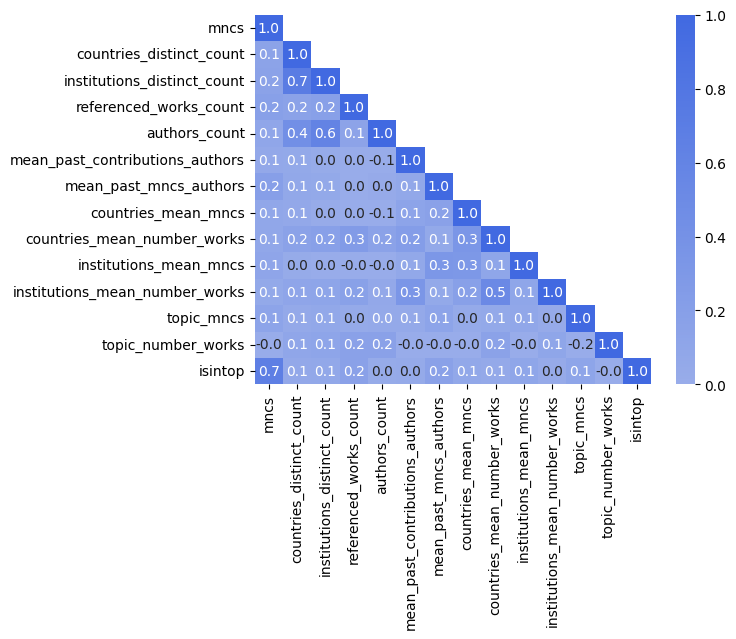

In [109]:
mask = np.triu(np.ones_like(data_corr, dtype=bool), k = 1)
cmap = sns.light_palette("royalblue", as_cmap=True)
sns.heatmap(data_corr, cmap = cmap, mask = mask, annot = True, fmt = ".1f", center = 0, vmin = 0, vmax = 1) #RdBu_r Spectral vlag
plt.grid(False)
plt.show()

# Linear Regression

In [120]:
X = data.drop(columns=["mncs", "isintop","review"])
X_9_features = X.drop(columns=["countries_mean_number_works",
                               "topic_number_works",
                               "institutions_mean_number_works"])
X_5_features =  X_9_features.drop(columns=["authors_count",
                                           "referenced_works_count",
                                           "mean_past_contributions_authors",
                                           "countries_distinct_count"])
y_true = data["mncs"]

In [112]:
model = LinearRegression()
rfe = RFE(model, n_features_to_select=2)
rfe.fit(X, y_true)

ranking_df = pd.DataFrame({
    'feature': X.columns,
    'ranking': rfe.ranking_,
    'selected': rfe.support_
}).sort_values('ranking')

print(ranking_df)

                            feature  ranking  selected
6               countries_mean_mncs        1      True
10                       topic_mncs        1      True
5            mean_past_mncs_authors        2     False
1       institutions_distinct_count        3     False
8            institutions_mean_mncs        4     False
0          countries_distinct_count        5     False
4   mean_past_contributions_authors        6     False
2            referenced_works_count        7     False
3                     authors_count        8     False
9    institutions_mean_number_works        9     False
11               topic_number_works       10     False
7       countries_mean_number_works       11     False


## _test on the training data_

In [113]:
model = LinearRegression()
model.fit(X=X,y=y_true)
y_pred = model.predict(X=X)

In [114]:
print(f"R2: {r2_score(y_pred = y_pred, y_true = y_true)}")
print(f"RMSE: {root_mean_squared_error(y_pred = y_pred, y_true = y_true)}")

R2: 0.10671593189775563
RMSE: 1.6143778259005215


## _cross validation_

very important to shuffle the dataset (because it's sorted by the target otherwise).

In [115]:
model = LinearRegression()
mean_r2_cv = cross_val_score(model, X=X, y=y_true, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="r2").mean()
mean_rmse_cv = -cross_val_score(model, X=X, y=y_true, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="neg_root_mean_squared_error").mean()
print(f"R2: {mean_r2_cv}")
print(f"RMSE: {mean_rmse_cv}")

R2: 0.10220205513938851
RMSE: 1.6139119821893417


In [116]:
model = LinearRegression()
mean_r2_cv = cross_val_score(model, X=X_9_features, y=y_true, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="r2").mean()
mean_rmse_cv = -cross_val_score(model, X=X_9_features, y=y_true, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="neg_root_mean_squared_error").mean()
print(f"R2: {mean_r2_cv}")
print(f"RMSE: {mean_rmse_cv}")

R2: 0.10147306371114684
RMSE: 1.6145397594156077


In [117]:
model = LinearRegression()
mean_r2_cv = cross_val_score(model, X=X_5_features, y=y_true, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="r2").mean()
mean_rmse_cv = -cross_val_score(model, X=X_5_features, y=y_true, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="neg_root_mean_squared_error").mean()
print(f"R2: {mean_r2_cv}")
print(f"RMSE: {mean_rmse_cv}")

R2: 0.07342418914346724
RMSE: 1.6389517365457689


# ElasticNet regression

## Manual nested cross_validation

In [121]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled)
data_scaled.columns = data.columns
y_true_scaled = data_scaled["mncs"]
X_scaled = data_scaled.drop(columns=["mncs", "isintop","review"])

In [122]:
model = ElasticNet()

In [39]:
## tuning preparation
param_grid = {
    "alpha": np.logspace(-2, 3, 3),
    "l1_ratio": np.linspace(0, 1, 3)
}
inner_cv = KFold(n_splits=3, shuffle=True, random_state=1)
grid = GridSearchCV(model, param_grid, cv=inner_cv, scoring="neg_mean_squared_error") # return a model with the best hyper-parameters
## testing preparation
outer_cv = KFold(n_splits=3, shuffle=True, random_state=2)
## nested cross_validation
nested_scores = - cross_val_score(grid, X, y_true, cv=outer_cv, scoring="neg_mean_squared_error")
print(nested_scores.mean())


c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.631e+03, tolerance: 1.043e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.598e+03, tolerance: 1.043e+00 Linear regression models with null weight for the l1 regularization term are more efficiently 

-0.9000848543982509


c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.220e+03, tolerance: 1.619e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [ ]:
nested_r2 = cross_val_score(grid, X_scaled, y_true_scaled, cv=outer_cv, scoring="r2")
print(nested_r2.mean())

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.631e+03, tolerance: 1.043e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.598e+03, tolerance: 1.043e+00 Linear regression models with null weight for the l1 regularization term are more efficiently 

0.09987273160875894


c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.220e+03, tolerance: 1.619e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


## Automatic Nested Cross Validation

In [124]:
model = ElasticNetCV(cv=5, l1_ratio=[0.1,0.5,0.9], alphas=[0.01, 0.1, 1])

In [125]:
mean_r2_cv = cross_val_score(model, X=X_scaled, y=y_true_scaled, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="r2").mean()
mean_rmse_cv = -cross_val_score(model, X=X_scaled, y=y_true_scaled, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="neg_root_mean_squared_error").mean()
print(f"R2: {mean_r2_cv}")
print(f"RMSE: {mean_rmse_cv}")

R2: 0.10139326152014527
RMSE: 0.9453206303253305


The RMSE is lower only because the data have been scaled... (The R2 is invariant to scaling)

# PCA

In [126]:
pca_modelling = sklearn.decomposition.PCA()
pca_modelling.fit(data_scaled)
data_pca = pca_modelling.transform(data_scaled)
data_pca = pd.DataFrame(data_pca)

In [127]:
components = pca_modelling.components_
features = data_scaled.columns

cos2 = components.T ** 2  # shape: (n_features, n_components)
cos2_df = pd.DataFrame(cos2, index=features, columns=[f'PC{i+1}' for i in range(pca_modelling.n_components_)])

contrib = (components.T ** 2) * 100
for i in range(contrib.shape[1]):
    total = contrib[:, i].sum()
    contrib[:, i] = contrib[:, i] / total * 100  

contrib_df = pd.DataFrame(contrib, index=features, columns=[f'PC{i+1}' for i in range(pca_modelling.n_components_)])


In [128]:
contrib_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
mncs,8.465924,4.808626,19.222336,2.715148,0.439586,11.402728,1.021850,0.028769,0.002980,0.125106,0.000999,0.023417,0.060635,51.450490,0.231406
countries_distinct_count,13.687297,11.803155,0.687323,3.678577,0.249855,0.125098,0.069091,12.368746,0.482892,1.371863,20.006053,2.038452,4.967507,0.215180,28.248913
institutions_distinct_count,15.766236,16.189788,0.951004,2.953973,0.426037,0.123716,0.024579,3.177383,0.000003,0.000081,0.508335,0.338722,0.094642,0.023891,59.421611
referenced_works_count,9.160154,0.003899,0.430451,24.021188,0.048353,10.156881,0.947885,0.001673,0.083804,0.294061,7.648171,45.203462,1.875241,0.013054,0.111724
authors_count,8.960519,18.033914,0.989080,2.679483,0.066853,0.003619,0.000386,6.794833,0.934146,2.906060,34.210574,2.883022,10.004560,0.486960,11.045989
review,5.361525,1.615487,0.646118,25.517822,0.587135,14.486369,0.811907,8.407000,0.021230,0.234650,0.819725,32.785742,8.001080,0.037638,0.666571
mean_past_contributions_authors,2.151589,4.795493,6.863276,2.006670,7.915796,17.700184,19.267225,15.740299,10.829628,0.592368,11.980592,0.023163,0.036109,0.075288,0.022320
mean_past_mncs_authors,2.726193,6.393958,3.707584,7.561253,7.085932,4.315954,28.600826,1.257469,17.602069,20.500766,0.032889,0.023014,0.067282,0.098438,0.026373
countries_mean_mncs,3.144400,9.696558,2.907680,7.725085,3.787975,2.215398,34.248542,2.689792,2.990539,14.554915,2.353615,2.345907,11.321873,0.016387,0.001334
countries_mean_number_works,11.996937,1.810807,16.224426,0.017817,0.379070,0.107044,6.303696,7.334960,3.360953,0.187851,1.335211,9.340136,41.485516,0.111550,0.004026


In [129]:
cos2_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
mncs,0.084659,0.048086,0.192223,0.027151,0.004396,0.114027,0.010218,0.000288,2.979619e-05,1.251058e-03,0.000010,0.000234,0.000606,5.145049e-01,0.002314
countries_distinct_count,0.136873,0.118032,0.006873,0.036786,0.002499,0.001251,0.000691,0.123687,4.828916e-03,1.371863e-02,0.200061,0.020385,0.049675,2.151797e-03,0.282489
institutions_distinct_count,0.157662,0.161898,0.009510,0.029540,0.004260,0.001237,0.000246,0.031774,2.605497e-08,8.065765e-07,0.005083,0.003387,0.000946,2.389057e-04,0.594216
referenced_works_count,0.091602,0.000039,0.004305,0.240212,0.000484,0.101569,0.009479,0.000017,8.380437e-04,2.940605e-03,0.076482,0.452035,0.018752,1.305355e-04,0.001117
authors_count,0.089605,0.180339,0.009891,0.026795,0.000669,0.000036,0.000004,0.067948,9.341461e-03,2.906060e-02,0.342106,0.028830,0.100046,4.869597e-03,0.110460
review,0.053615,0.016155,0.006461,0.255178,0.005871,0.144864,0.008119,0.084070,2.123005e-04,2.346498e-03,0.008197,0.327857,0.080011,3.763846e-04,0.006666
mean_past_contributions_authors,0.021516,0.047955,0.068633,0.020067,0.079158,0.177002,0.192672,0.157403,1.082963e-01,5.923681e-03,0.119806,0.000232,0.000361,7.528833e-04,0.000223
mean_past_mncs_authors,0.027262,0.063940,0.037076,0.075613,0.070859,0.043160,0.286008,0.012575,1.760207e-01,2.050077e-01,0.000329,0.000230,0.000673,9.843811e-04,0.000264
countries_mean_mncs,0.031444,0.096966,0.029077,0.077251,0.037880,0.022154,0.342485,0.026898,2.990539e-02,1.455491e-01,0.023536,0.023459,0.113219,1.638676e-04,0.000013
countries_mean_number_works,0.119969,0.018108,0.162244,0.000178,0.003791,0.001070,0.063037,0.073350,3.360953e-02,1.878509e-03,0.013352,0.093401,0.414855,1.115497e-03,0.000040


In [130]:
pca_modelling.explained_variance_ratio_

array([0.1889692 , 0.12991085, 0.11182367, 0.10081959, 0.07553612,
       0.07043015, 0.05643351, 0.05252096, 0.04277745, 0.04221853,
       0.0347931 , 0.0300694 , 0.02626609, 0.02161386, 0.01581753])

<Axes: >

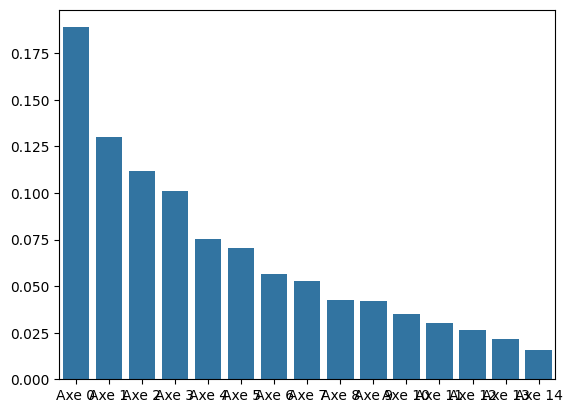

In [131]:
sns.barplot(x = [f"Axe {i}" for i in range(len(pca_modelling.explained_variance_ratio_))], y = pca_modelling.explained_variance_ratio_)


In [132]:
data_pca = data_pca.loc[:,:1]
data_pca["isintop"] = data["isintop"]
data_pca.columns = ["Axis 1", "Axis 2", "isintop"]

<Axes: xlabel='Axis 1', ylabel='Axis 2'>

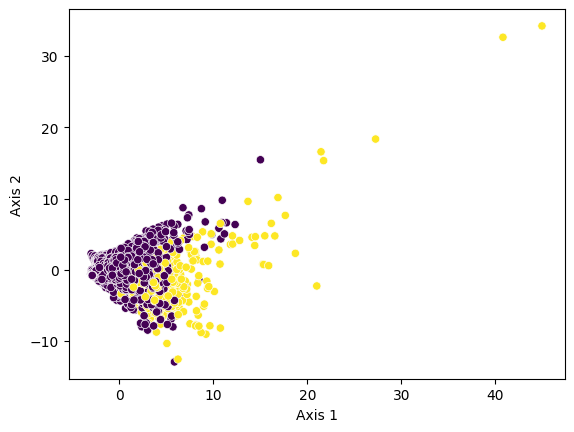

In [133]:
sns.scatterplot(x = data_pca.iloc[:,0], y = data_pca.iloc[:,1], c=data_pca["isintop"])

# Logistic classification on the PCA

### Simple 

In [90]:
data_pca

,Axis 1,Axis 2,isintop
0,-2.381348,-0.799496,False
1,-2.807354,-0.663772,False
2,-2.551692,-0.671115,False
3,-1.929753,0.119347,False
4,-1.669576,0.321364,False
...,...,...,...
23811,3.483948,1.412377,False
23812,0.710888,-0.293121,False
23813,2.926575,1.464853,False
23814,3.586412,0.833141,False


In [96]:
train, test = sklearn.model_selection.train_test_split(data_pca)
logistic_modelling = sklearn.linear_model.LogisticRegression()
logistic_modelling.fit(X = train.iloc[:,:2], y = train["isintop"])
y_pred = logistic_modelling.predict(test.iloc[:,:2])
y_true = test["isintop"]

In [92]:
f1 = sklearn.metrics.f1_score(y_true, y_pred)
accuracy = sklearn.metrics.accuracy_score(y_true, y_pred)
precision = sklearn.metrics.precision_score(y_true, y_pred)
recall = sklearn.metrics.recall_score(y_true, y_pred)

In [93]:
print(f"Accuracy: {accuracy}")
print(f"Precision:{precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

Accuracy: 0.9177023849512932
Precision:0.6656441717791411
Recall: 0.362876254180602
F1: 0.4696969696969697


Text(0.5, 1.0, 'dataset')

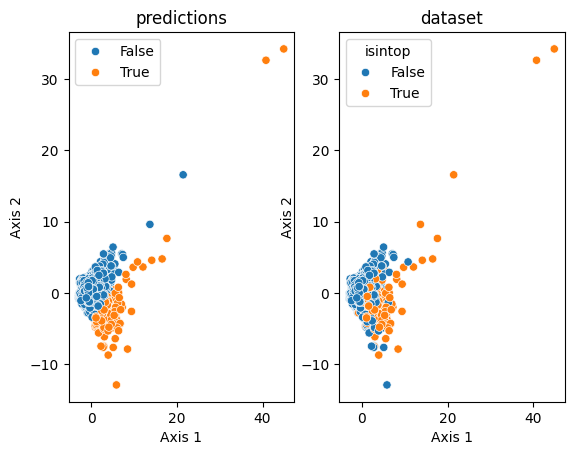

In [94]:
fig, axes = plt.subplot_mosaic([["A","B"]])         
sns.scatterplot(x = test.iloc[:,0], y = test.iloc[:,1], hue=y_pred, ax = axes["A"])
sns.scatterplot(x = test.iloc[:,0], y = test.iloc[:,1], hue=y_true, ax = axes["B"])
axes["A"].set_title("predictions")
axes["B"].set_title("dataset")

### Cross validation

In [66]:
logistic_modelling = sklearn.linear_model.LogisticRegression()
scores = {}
for i in ["accuracy", "precision_macro", "recall_macro", "f1_macro"]:
    score = sklearn.model_selection.cross_val_score(logistic_modelling, 
                                                    X=data_pca.iloc[:,:2],
                                                    y=data_pca["isintop"],
                                                    scoring=i)
    scores[i] = score.mean()
print(f"Accuracy: {scores["accuracy"]}")
print(f"Precision:{scores["precision_macro"]}")
print(f"Recall: {scores["recall_macro"]}")
print(f"F1: {scores["f1_macro"]}")

Accuracy: 0.9103124102615089
Precision:0.8038588417214004
Recall: 0.6616846901294015
F1: 0.6788898141226688


# Random Forest Classification

In [69]:
logistic_modelling = sklearn.ensemble.RandomForestClassifier(bootstrap=True, random_state=1, class_weight="balanced") # class_weight="balanced" address the class imbalance
scores = {}
for i in ["accuracy", "precision_macro", "recall_macro", "f1_macro"]:
    score = sklearn.model_selection.cross_val_score(logistic_modelling, 
                                                    X=data_pca.iloc[:,:2],
                                                    y=data_pca["isintop"],
                                                    scoring=i)
    scores[i] = score.mean()
print(f"Accuracy: {scores["accuracy"]}")
print(f"Precision:{scores["precision_macro"]}")
print(f"Recall: {scores["recall_macro"]}")
print(f"F1: {scores["f1_macro"]}")

Accuracy: 0.8956157992981513
Precision:0.7282824363106172
Recall: 0.6589414368052771
F1: 0.6690302680189647


# Boosting Classification

In [138]:
param_grid = {
    'n_estimators': [20, 50],
    'learning_rate': [0.03, 0.05],
    'max_depth': [3, 2],
    'subsample': [0.8, 0.7]
}

grid = GridSearchCV(GradientBoostingClassifier(), param_grid, cv=5)
grid.fit(X=data_pca.iloc[:,:2], y=data_pca["isintop"])
print(grid.best_params_)
score = cross_val_score(grid, X=data_pca.iloc[:,:2], y=data_pca["isintop"], scoring="f1_macro").mean()

{'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
